In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report


In [2]:
print("Downloading Fashion MNISt dataset....")

fashion_mnist=fetch_openml("Fashion-MNIST",version=1,as_frame=False)
x=fashion_mnist.data
y=fashion_mnist.target.astype(int)

print(f"Total dataset size:{x.shape[0]} images, each with {x.shape[1]} pixels.")

Total dataset size:70000 images, each with 784 pixels.


In [3]:
x=x[:10000]
y=y[:10000]

In [5]:

x_train,x_test,y_train,y_test=train_test_split(
    x,y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Training images: {x_train.shape[0]}")
print(f"Testing images: {x_test.shape[0]}")

Training images: 8000
Testing images: 2000


In [10]:
scalar = StandardScaler()
x_train = scalar.fit_transform(x_train)
x_test = scalar.transform(x_test)

In [12]:
print("\nTraining Linear SVM...")
linear_svm=SVC(kernel='linear')
linear_svm.fit(x_train,y_train)
y_pred_linear=linear_svm.predict(x_test)
linear_accuracy=accuracy_score(y_test,y_pred_linear)
print("Linear SVM Accuracy:",
      linear_accuracy*100,"%")


Training Linear SVM...
Linear SVM Accuracy: 80.75 %


In [14]:
print("\nTraning RBF SVM...")
rbf_svm=SVC(
    kernel='rbf',
    gamma='scale'
)
rbf_svm.fit(x_train,y_train)
y_pred_rbf=rbf_svm.predict(x_test)
rbf_accuracy=accuracy_score(y_test,y_pred_rbf)
print("RBF SVM Accuracy:",
      rbf_accuracy*100,"%")


Traning RBF SVM...
RBF SVM Accuracy: 85.25 %


In [16]:
print("\n---Linaer SVM Classification Report---")
print(classification_report(y_test,y_pred_linear))
print("---RBF SVM Classification Report---")
print(classification_report(y_test,y_pred_rbf))


---Linaer SVM Classification Report---
              precision    recall  f1-score   support

           0       0.68      0.83      0.74       189
           1       0.95      0.97      0.96       205
           2       0.64      0.71      0.67       203
           3       0.83      0.79      0.81       204
           4       0.65      0.62      0.63       195
           5       0.91      0.92      0.91       198
           6       0.63      0.50      0.55       204
           7       0.89      0.89      0.89       204
           8       0.97      0.95      0.96       198
           9       0.92      0.92      0.92       200

    accuracy                           0.81      2000
   macro avg       0.81      0.81      0.81      2000
weighted avg       0.81      0.81      0.81      2000

---RBF SVM Classification Report---
              precision    recall  f1-score   support

           0       0.79      0.81      0.80       189
           1       1.00      0.96      0.98       205
  

(0.0, 100.0)

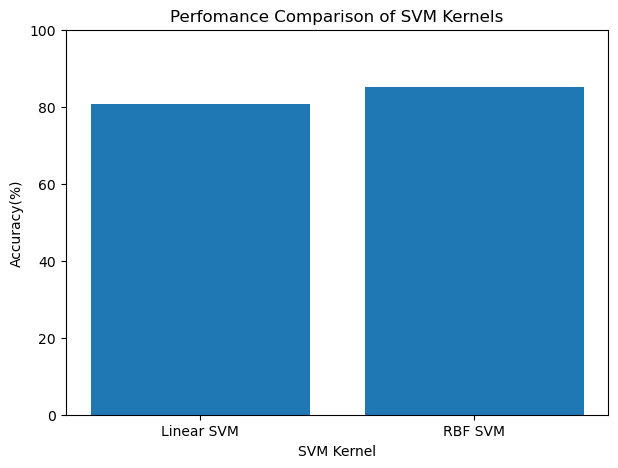

In [17]:
models=['Linear SVM','RBF SVM']
accuracy=[linear_accuracy*100,rbf_accuracy*100]
plt.figure(figsize=(7,5))
bars=plt.bar(models,accuracy)
plt.ylabel("Accuracy(%)")
plt.xlabel("SVM Kernel")
plt.title("Perfomance Comparison of SVM Kernels")
plt.ylim(0,100)